# Credit Card Fraud Detection
## Notebook 1: EDA

The goal of this project is to build a model that flags fraudulent credit card transactions. I'm using a real, anonymized dataset of about 285,000 transactions from European cardholders.

Before doing any modeling, I want to look at the data first. How many rows there are, whether anything's missing, and most importantly, how rare fraud actually is. That last part shapes almost every decision I make later, like which metrics I trust, how I split the data, and how I deal with the imbalance. So it's worth slowing down here.

A quick note on the columns. Most of them (`V1` through `V28`) are anonymized. The bank couldn't share raw transaction details for privacy reasons, so what we get instead is the output of PCA, a technique that compresses the original features into unlabeled numeric columns. I don't know what `V14` or `V17` actually represent, and that's fine, the model can still pick up patterns from them. The rest are `Time` (seconds since the first transaction in the dataset), `Amount` (transaction dollar amount), and `Class`, the label I'm trying to predict: 0 for normal, 1 for fraud.

### Step 1 - Loading the Data & Looking at the Basics 

In [2]:
import pandas as pd      # for loading and manipulating the tabular data
import numpy as np       # for numeric operations (used later in this project)
import matplotlib.pyplot as plt  # for building charts
import seaborn as sns    # built on top of matplotlib, makes nicer statistical charts with less code

# Load the full dataset into a pandas DataFrame - one row per transaction
df = pd.read_csv('../data/creditcard.csv')

print(df.shape)      # gives you (rows, columns). You're expecting (284807, 31)
print(df.head())     # eyeballs the first 5 rows so you can visually confirm the columns look like what was described (Time, V1-V28, Amount, Class)
print(df.info())     # shows you the dtype of every column and how many non-null values it has
print(df.isnull().sum())  # counts missing values per column - fraud detection models can't handle gaps, so we need to know upfront if any exist

Matplotlib is building the font cache; this may take a moment.


(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

### Step 1.2 - The class imbalance chart

Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.173%


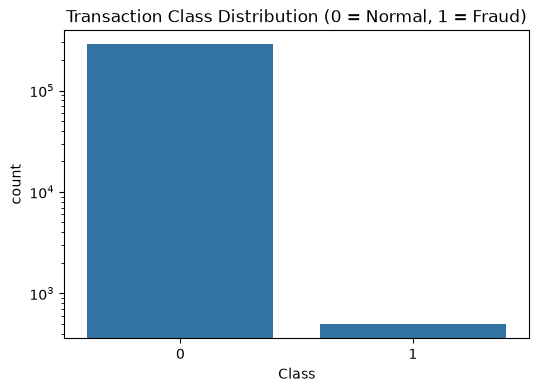

In [3]:
# Count how many transactions fall into each class (0 = normal, 1 = fraud)
fraud_counts = df['Class'].value_counts()
print(fraud_counts)

# Class is either 0 or 1, so the average of the whole column IS the fraud rate
# (e.g. if 1 out of 1000 rows is fraud, the average of the column is 0.001 -> 0.1%)
print(f"Fraud percentage: {df['Class'].mean() * 100:.3f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)  # bar chart: one bar per class, height = number of transactions
plt.title('Transaction Class Distribution (0 = Normal, 1 = Fraud)')
plt.yscale('log')  # log scale because the difference is so extreme - on a normal scale, the fraud bar would be invisible
plt.savefig('../dashboard/class_imbalance.png')  # save a copy of the chart as an image file, used later in the write-up/dashboard
plt.show()

0.17% fraud is the single most important number in this whole project. It's why accuracy is basically a useless metric here. A model that predicted "not fraud" on every single transaction would still be 99.83% accurate, and it would catch exactly zero fraud. Pretty much every choice I make from here on, using precision and recall instead of accuracy, stratifying the train/test split, using class_weight, trying SMOTE, comes back to this one fact.

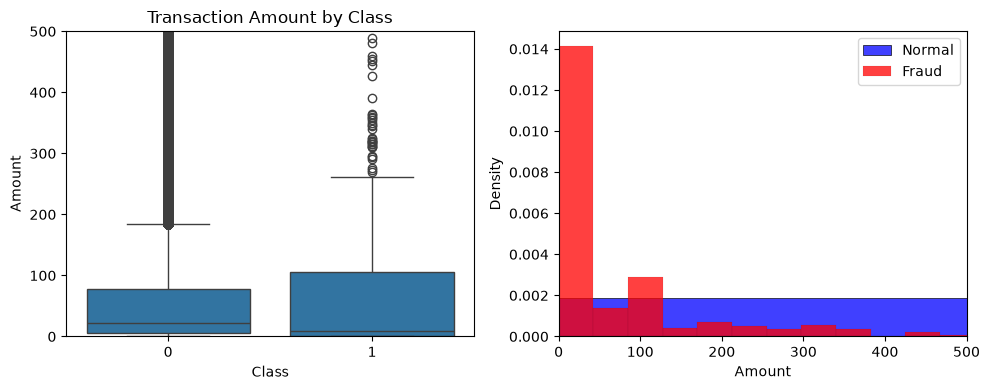

In [4]:
# Set up a figure with two charts side by side
plt.figure(figsize=(10,4))

# --- Chart 1: Boxplot comparing amount spread for Normal vs Fraud ---
plt.subplot(1,2,1)  # 1 row, 2 columns, this is chart #1
sns.boxplot(x='Class', y='Amount', data=df)  # boxplot shows median, quartiles, outliers
plt.title('Transaction Amount by Class')
plt.ylim(0, 500)  # zoom the y-axis into $0-$500 so a few huge outliers don't squash the view

# --- Chart 2: Overlapping histograms of amount for each class ---
plt.subplot(1,2,2)  # chart #2, same row
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Normal', stat='density')
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', stat='density')
# stat='density' rescales both histograms so they're comparable even though
# there are way more Normal transactions than Fraud ones
plt.legend()
plt.xlim(0, 500)  # same zoom as the boxplot, for a fair visual comparison

plt.tight_layout()  # prevents the two charts from overlapping/cutting off labels
plt.savefig('../dashboard/amount_distribution.png')  # save before showing
plt.show()

What I'm trying to figure out here: do fraudulent transactions tend to happen at different dollar amounts than normal ones? Are fraudsters running small test charges, or going for bigger one-off hits?

The boxplot gives me the typical range for each class plus outliers, and the histogram shows the actual shape of where transactions pile up. I'll zoom into $0-$500 for both, since a handful of large outliers would otherwise squash the scale and make everything else unreadable.

I'm going to describe honestly what shows up rather than guess ahead of time. The pattern here could easily surprise me.

The boxplot shows something I wasn't expecting going in. Class 0 (normal) has a lower median and a tighter box, but plenty of outliers stretching all the way up toward $500. Class 1 (fraud) actually has a higher median and taller box than normal, but its outliers cut off much lower, around $200-250. No fraud transactions way up near $500 in this sample.

The histogram fills in the rest of the picture. Fraud has a much taller spike right in the $0-25 bin, proportionally, than normal does at that same range.

So putting those together: fraud is heavily concentrated at very low dollar amounts, but at the same time its median and typical range sit a bit higher than normal's, and it has far fewer high-dollar outliers than normal does. A bit of a mixed signal, honestly.

For modeling, my takeaway is that Amount probably isn't going to be a strong standalone predictor. The two classes overlap way too much in the low range. But the shapes aren't identical either, so I'll keep it in as a feature rather than drop it.

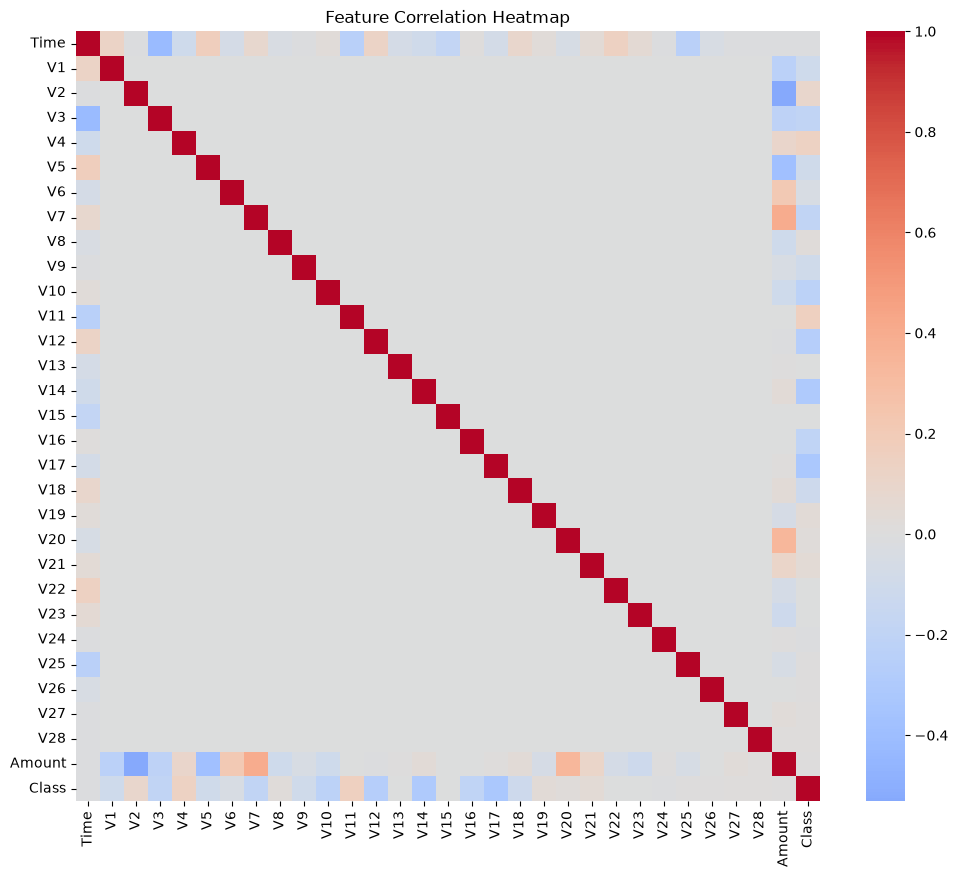

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [5]:
# Compute correlation between every pair of numeric columns in the dataset
# (correlation = how strongly two columns move together, from -1 to +1)
corr = df.corr()

# Set up a large figure so the heatmap is readable with 31 columns
plt.figure(figsize=(12,10))

# Draw the heatmap: red = positive correlation, blue = negative, white = ~none
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.savefig('../dashboard/correlation_heatmap.png')  # save before showing
plt.show()

# Pull out just the correlations with the Class column (fraud label),
# sorted from most positively correlated to most negatively correlated
print(corr['Class'].sort_values(ascending=False))

Next I want to see which of the anonymized V1-V28 features move together with Class the most, in either direction: positively (goes up when fraud happens) or negatively (goes down when fraud happens).

Reading the printed list: the top rows (highest positive numbers) and the bottom rows (most negative, closest to -1) are the features most tied to fraud. Anything near 0 basically has no linear relationship with it. I'll jot down the strongest few in each direction, since I want to check later whether the trained model actually picks up on these same features.

The strongest fraud-correlated features, on the negative side, are V17 (-0.326), V14 (-0.302), V12 (-0.261), and V7 (-0.187). These tend to drop when a transaction is fraudulent. On the positive side it's V11 (0.155), V4 (0.133), and V2 (0.091). These tend to rise.

None of these are anywhere close to plus or minus 1, so no single feature is going to solve fraud detection by itself. The strongest one, V17, is only a moderate relationship. That tells me the model is going to need to combine a bunch of features together to actually separate fraud from normal transactions, which makes sense given how anonymized and compressed these columns already are.

I'll keep V17, V14, V12, and V4 in mind for later. If these show up as important features once I train a model, that's a good sign it's picking up on real signal instead of noise.

One more thing worth noting: Amount (0.0056) and Time (-0.0123) are both basically at 0 correlation with Class. That lines up with what the boxplot and histogram showed earlier. Amount alone isn't much of a signal, since both classes overlap so heavily.